#Python Scripting Assignment

In [ ]:
# -----------------------------
# TASK 1: File Operations + Data Processing
# -----------------------------

# Step 1: Create and write sample data into a file
data = """Vaishnavi,Pen,5,10
Amit,Notebook,2,50
Neha,Pencil,10,5
Rahul,Bag,1,700
Priya,Eraser,6,3
"""

with open("sales_data.txt", "w") as file:
    file.write(data)

print("✅ sales_data.txt file created successfully!\n")


# Step 2: Read file and process data
total_sales = 0
records = []

with open("sales_data.txt", "r") as file:
    lines = file.readlines()

for line in lines:
    name, item, qty, price = line.strip().split(",")
    qty = int(qty)
    price = float(price)

    bill = qty * price
    total_sales += bill

    records.append({
        "name": name,
        "item": item,
        "quantity": qty,
        "price": price,
        "bill": bill
    })

# Step 3: Data Processing Results
average_sale = total_sales / len(records)
highest_bill_record = max(records, key=lambda x: x["bill"])

print("📌 Processed Results:")
print("✅ Total Sales:", total_sales)
print("✅ Average Sale:", round(average_sale, 2))
print("✅ Highest Bill:", highest_bill_record["name"], "=>", highest_bill_record["bill"])
print("\n")


# Step 4: Save processed report to another file
with open("report.txt", "w") as report:
    report.write("------ SALES REPORT ------\n")
    report.write(f"Total Sales: {total_sales}\n")
    report.write(f"Average Sale: {round(average_sale, 2)}\n")
    report.write(f"Highest Bill: {highest_bill_record['name']} => {highest_bill_record['bill']}\n\n")

    report.write("Details:\n")
    for r in records:
        report.write(f"{r['name']} bought {r['item']} | Qty={r['quantity']} | Price={r['price']} | Bill={r['bill']}\n")

print("✅ report.txt generated successfully!")


✅ sales_data.txt file created successfully!

📌 Processed Results:
✅ Total Sales: 918.0
✅ Average Sale: 183.6
✅ Highest Bill: Rahul => 700.0


✅ report.txt generated successfully!


Task 2: Develop a Simple Web Scraper to Extract Data from a Website
In this task, we will scrape quotes and author names from a website using `requests` and `BeautifulSoup`.
Website: http://quotes.toscrape.com


In [ ]:
!pip install requests beautifulsoup4


In [ ]:
import requests
from bs4 import BeautifulSoup
import csv

# ✅ Website to scrape
url = "http://quotes.toscrape.com"

# Step 1: Request the website
response = requests.get(url)

if response.status_code == 200:
    print("✅ Website connected successfully!")
else:
    print("❌ Failed to connect to website")
    exit()

# Step 2: Parse HTML content
soup = BeautifulSoup(response.text, "html.parser")

# Step 3: Extract Quotes and Authors
quotes = soup.find_all("div", class_="quote")

data = []

for q in quotes:
    quote_text = q.find("span", class_="text").text
    author = q.find("small", class_="author").text
    data.append([quote_text, author])

# Step 4: Save extracted data to CSV file
with open("quotes.csv", "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["Quote", "Author"])  # Header
    writer.writerows(data)

print("✅ Data scraped successfully and saved in quotes.csv")


✅ Website connected successfully!
✅ Data scraped successfully and saved in quotes.csv


In [ ]:
import pandas as pd

df = pd.read_csv("quotes.csv")
df.head(10)


,Quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe
5,“Try not to become a man of success. Rather be...,Albert Einstein
6,“It is better to be hated for what you are tha...,André Gide
7,"“I have not failed. I've just found 10,000 way...",Thomas A. Edison
8,“A woman is like a tea bag; you never know how...,Eleanor Roosevelt
9,"“A day without sunshine is like, you know, nig...",Steve Martin


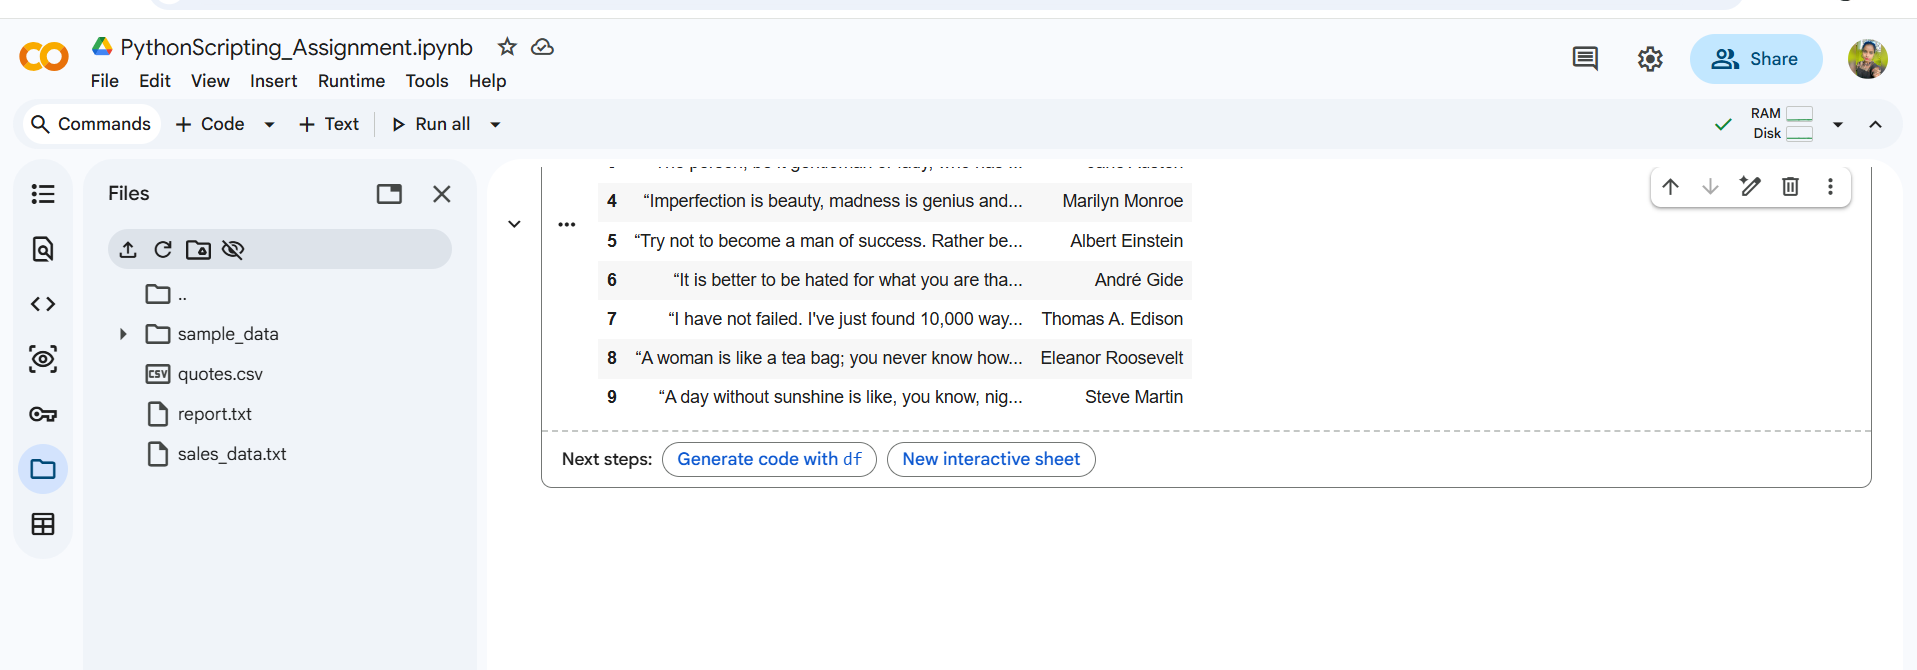